# Target: 'Gender' classes[M | F | Autre]: 5 roots: Training two custom bilstms
# Feature extraction with EfficientNetV2B0

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from tensorflow.keras.layers import Input,LSTM,Bidirectional,Dense,BatchNormalization,Activation,MaxPooling2D,Dropout,Reshape,Conv2D,Flatten,GlobalAveragePooling2D,TimeDistributed

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import F1Score , Precision, Accuracy, BinaryAccuracy, Recall ,AUC
import cv2
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input ,EfficientNetV2B0

2025-12-22 00:30:11.938358: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766363412.120910      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766363412.178806      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### Fixing Seed To ensure reproducibility

In [2]:
# # Set seed for reproducibility
# import random
# SEED = 42
# tf.random.set_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)
# os.environ['PYTHONHASHSEED'] = str(SEED)
# os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Confuguration


In [3]:
#metrics
f1_score=F1Score()
precision = Precision()
recall =Recall()
binary_accuracy=BinaryAccuracy()
# accuracy = Accuracy()
metrics=[f1_score,precision,recall,'accuracy',binary_accuracy]

class_position_in_path=8

I0000 00:00:1766363426.402751      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
TARGET_TYPE='Gender'
EPOCHS=30
LR=1e-3
LOSS_FUNCTION='binary_crossentropy'
GRAY_SCALING=False

In [5]:
print(tf.__version__)

2.18.0


# Data Preparation

In [6]:
def get_paths(parent_folder):
    import os
    files={}
    for i in os.walk(parent_folder):
        if i[-1]:
            files[i[0]]=[]
            image_name= i[-1][0]
#             files[i[0]].append(image_name)
            for image_name in i[-1]:
                files[i[0]].append(image_name)
    paths=[]
    for parent_path  in files.keys() :
        for image_name in files[parent_path]:
            paths.append(os.path.join(parent_path,image_name))
    return paths

def remove_not_image_files(paths):
    for p in paths:
        if not p.endswith('.png') and  not p.endswith('.jpg') and not p.endswith('.jpeg') and not p.endswith('.bmp'):
            print("path will be removed:"+p)
            paths.remove(p)
        else:
            try:
                plt.imread(p)
            except:
                paths.remove(p)
                print("cannot read path, will be removed:"+p)

    return paths

In [7]:
def preprocess_paths(parent_path):
    paths=get_paths(parent_path)
    n_paths_before=len(paths)
    i=0
    while(i<3):
        paths=remove_not_image_files(paths)
        i=i+1
    n_paths_after=len(paths)
    print(f"{n_paths_before - n_paths_after} paths have been removed from {n_paths_before}")
    return paths

In [8]:
parent_folder ='/kaggle/input/5-arabic-roots'
paths=preprocess_paths(parent_folder)

path will be removed:/kaggle/input/5-arabic-roots/corpus1/Corpus_Apprentissage_CNN_5_racines.xml
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_16_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_24_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_14_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/3_honna/Image_16_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/3_honna/Image_24_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�sent/11_ghaeb/2_hom/Image_24_Arabic Transparent_4.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�sent/11_ghaeb/2

In [9]:
def get_ref_from_path(path,folder_position):
    if  path.startswith('/'):
        folder_position= folder_position+1
    return path.split('/')[folder_position]

In [10]:
def get_refs_from_paths(paths,folder_position):
    labels=[]
    for path in paths:
        labels.append(get_ref_from_path(path,folder_position))
    return labels

In [11]:
paths[0]

'/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/10_moukhatab/2_antouma/Image_24_Arabic Transparent_15472.png'

## Choosing the target

In [12]:
refs=get_refs_from_paths(paths,class_position_in_path)

## Prepare dataframe:

In [13]:
d = {'path': paths, 'ref':refs}
df =pd.DataFrame.from_dict(d)

In [14]:
df

,path,ref
0,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2_antouma
1,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2_antouma
2,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2_antouma
3,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2_antouma
4,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2_antouma
...,...,...
1011,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,0_houa
1012,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,0_houa
1013,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,0_houa
1014,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,0_houa


In [15]:
masculin = [
    '3_masculin',
    '0_houa',
    '2_antouma',
    '2_houma_m',
    '3_antom',
    '4_hom',
    '0_anta',
    '3_hom',
    '1_houma_m',
    '3_antouma',
    '1_anta',
    '0_ana',
    '2_hom'
]
feminin = [
    '4_feminin',
    '3_houma_f',
    '1_hya',
    '5_honna',
    '4_antonna',
    '3_honna',
    '4_antonna',
    '4_feminin',
    '2_anti',
    '2_antonna',
    '4_honna',
    '0_anti',
    '4_antom',
    '5_antonna',
    '1_anti'
]
autres = [
    '7_marfou3',
    '8_mansoub'
]

In [16]:
df['ref0'] = df['ref']
df['ref'] = df['ref0'].map(
    lambda x: 'male' if x in masculin else
              'female' if x in feminin else
              'autre')

In [17]:
SELECTED_CLASS_NAMES=['male','female','autre']

In [18]:
df = df[df['ref'].isin(SELECTED_CLASS_NAMES)]

In [19]:
df['ref'].value_counts()

ref
male      544
female    375
autre      97
Name: count, dtype: int64

In [20]:
df['ref'].value_counts().index

Index(['male', 'female', 'autre'], dtype='object', name='ref')

## Select necessary words. 

In [21]:
def ref_to_label(refs:list):
    classes=sorted(list(set(refs)))
    labels = []
    labels_refs_map={}
    for ref in refs:
        labels_refs_map[classes.index(ref)]=ref
        labels.append(str(classes.index(ref)))
    return labels ,labels_refs_map
def prepare_dataframe(paths,refs):
    """
    Role:
        - Prepare dataframe  that conatains the paths of the images and its corresponding labels.
    Inputs:
        - paths : list()
        - labels: list()
    Outputs:
        df : pd.Dataframe()
    """
    import pandas as pd
    labels,REFS_LABELS_MAP = ref_to_label(refs)
    d = {'path': paths, 'ref':refs,'label':labels}
    df =pd.DataFrame.from_dict(d)
    return df,REFS_LABELS_MAP
# test:
df,REFS_LABELS_MAP =prepare_dataframe(df.path.values,df.ref.values)
df,REFS_LABELS_MAP

(                                                   path   ref label
 0     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...  male     2
 1     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...  male     2
 2     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...  male     2
 3     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...  male     2
 4     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...  male     2
 ...                                                 ...   ...   ...
 1011  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...  male     2
 1012  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...  male     2
 1013  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...  male     2
 1014  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...  male     2
 1015  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...  male     2
 
 [1016 rows x 3 columns],
 {2: 'male', 1: 'female', 0: 'autre'})

## Exploaratory data analysis

### Class Distribution 

In [22]:
#plot function
def show_plot(path):
    import matplotlib.pyplot as plt
    img = plt.imread(path)
    plt.imshow(img)

In [23]:
#plot function
def plot_distribution(classe_names,distribution,subset_name):
    plt.style.use('seaborn-dark-palette')
    classes=classe_names
    values =distribution
    plt.figure(figsize = (20, 5))
    plt.bar(classes, values,width = 0.7)

    plt.xlabel("Gender id")
    plt.ylabel("Nb. words")
    plt.title(f"Repartition of {sum(values)} words in the {subset_name} data")
    def addlabels(x,y):
        for i in range(len(x)):
            plt.text(i, y[i], y[i], ha = 'center',color='black',style='italic',size="x-large")
    addlabels(classes,values)

In [24]:
series = df['ref'].value_counts()
values= series.values
keys = series.index

In [25]:
keys, len(keys)

(Index(['male', 'female', 'autre'], dtype='object', name='ref'), 3)

/tmp/ipykernel_20/4200485447.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


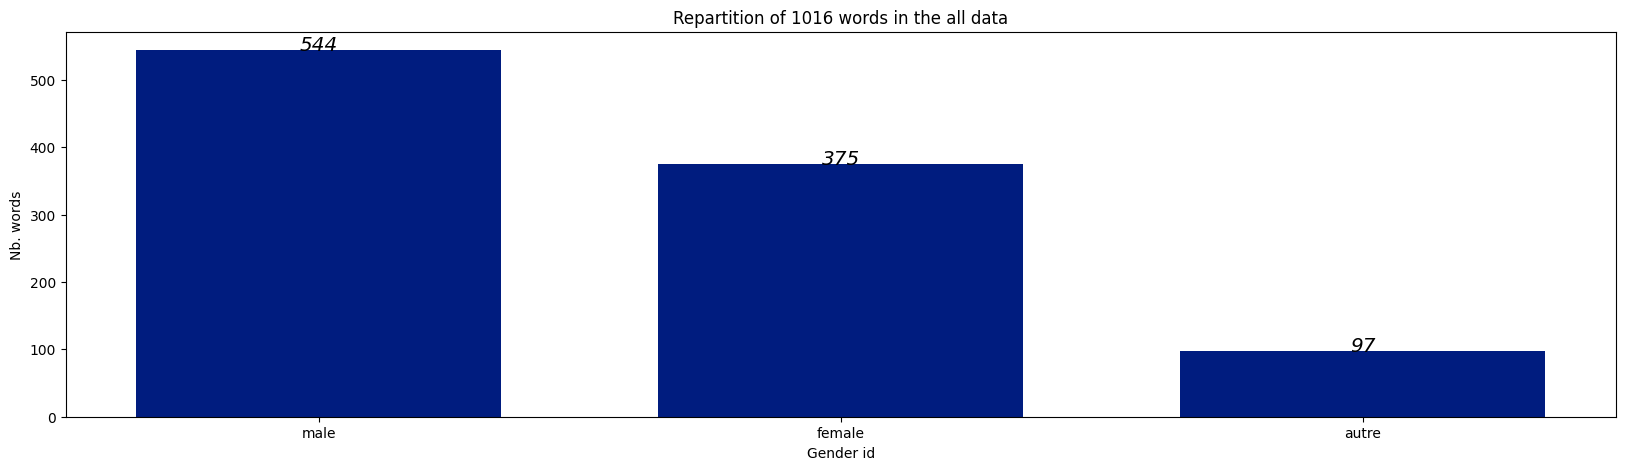

In [26]:
plot_distribution(keys,values,'all')

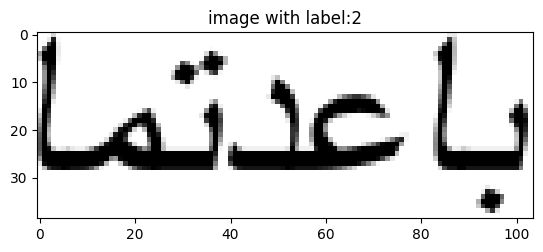

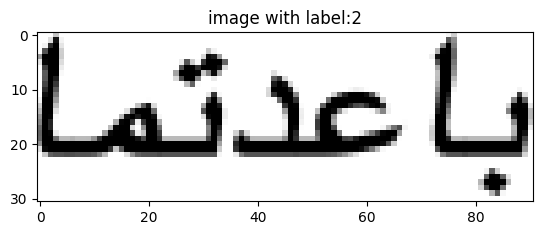

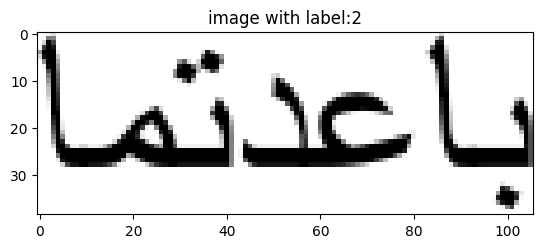

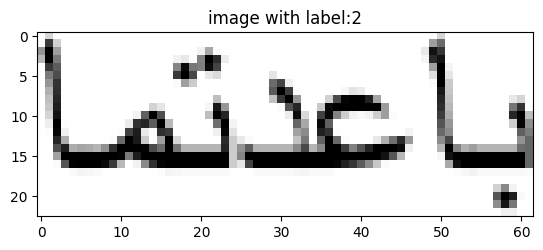

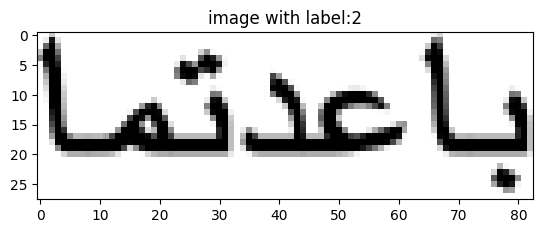

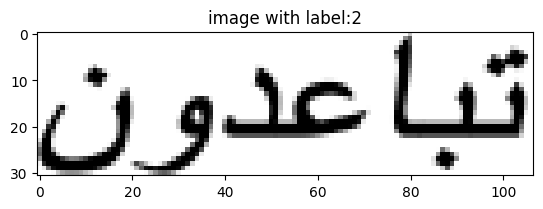

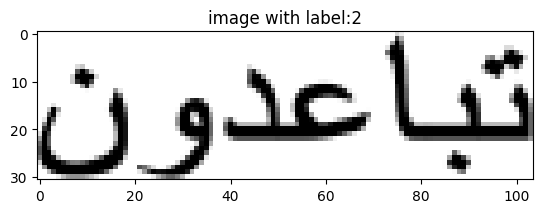

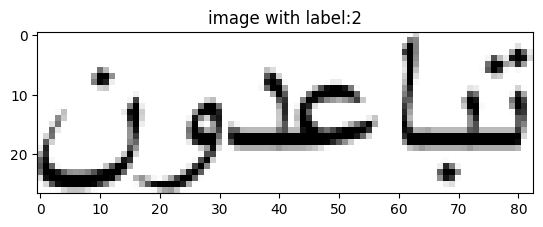

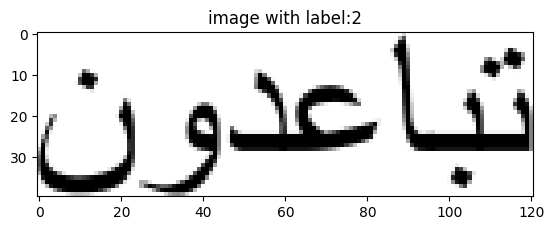

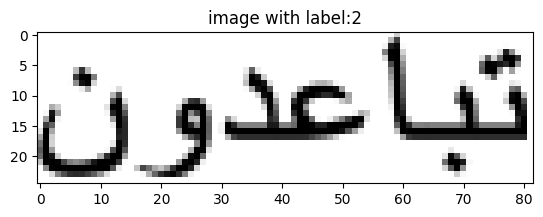

In [27]:
for i,path in enumerate(df['path'][:10]):
    im = cv2.imread(path)
    plt.figure()
    plt.title("image with label:"+df['label'][i])
    plt.imshow(im)

## split data :train ,test ,val

In [28]:
from sklearn.model_selection import train_test_split
train_df,test_df = train_test_split(df,test_size=0.2,shuffle=True,stratify=df['label'])
# val_df,test_df = train_test_split(test_df,test_size=0.5,shuffle=True,stratify=test_df['label'])

In [29]:
train_series = train_df['ref'].value_counts()
train_values = train_series.values
train_keys = train_series.index

/tmp/ipykernel_20/4200485447.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


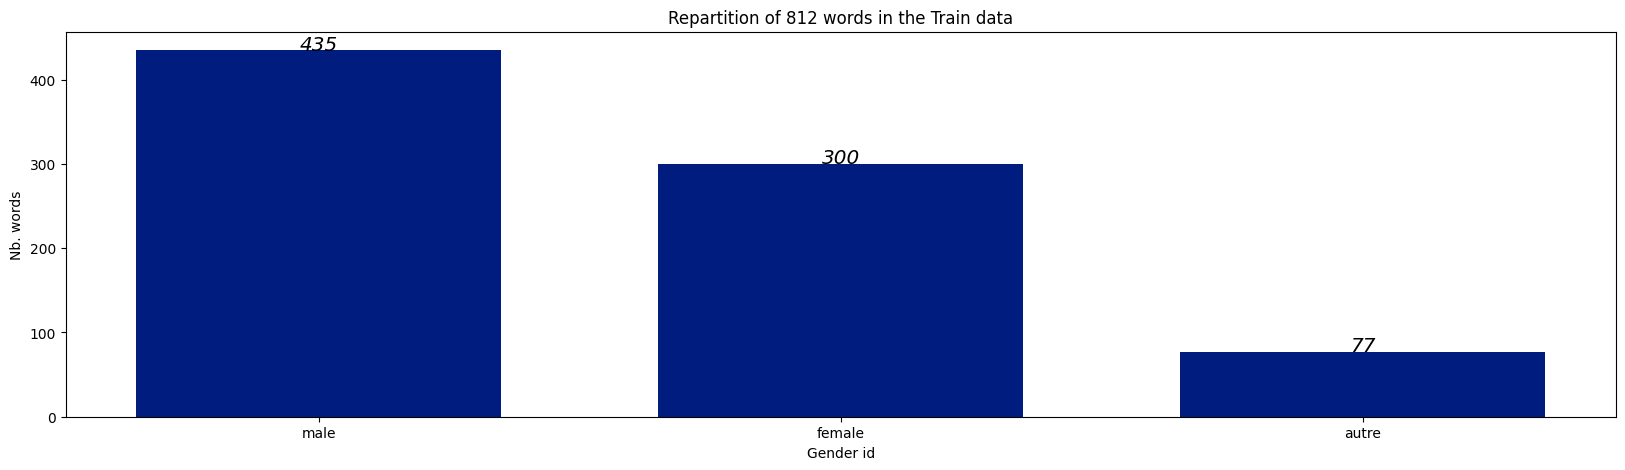

In [30]:
plot_distribution(train_keys,train_values,'Train')

## Test data

In [31]:
test_series = test_df['ref'].value_counts()
test_values = test_series.values
test_keys = test_series.index

/tmp/ipykernel_20/4200485447.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


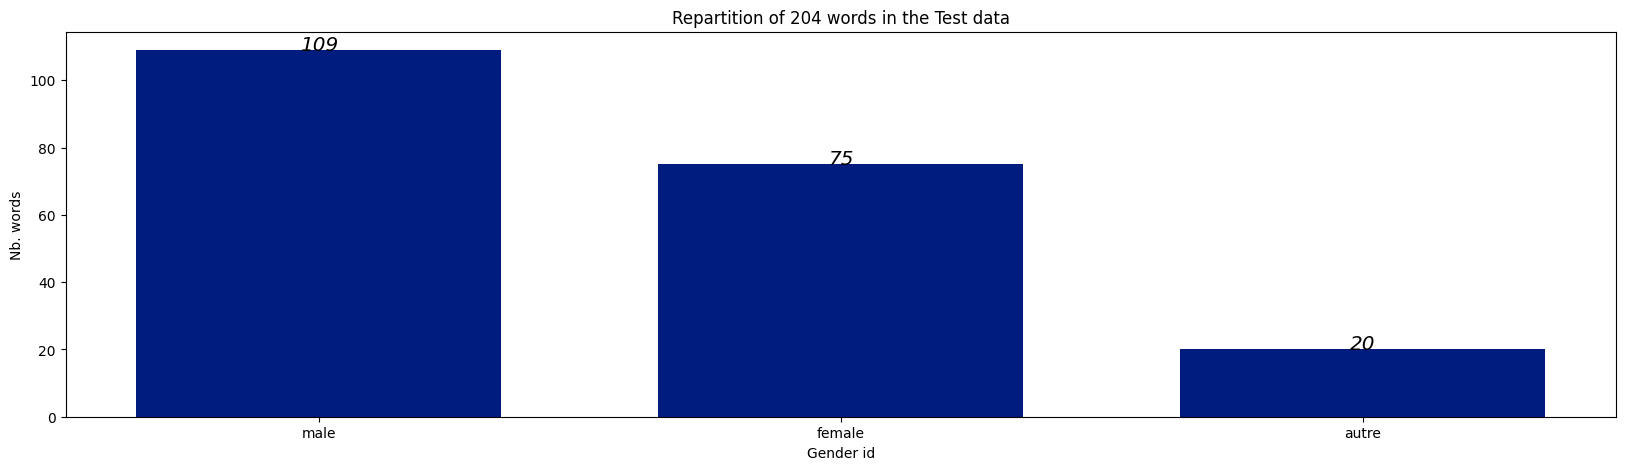

In [32]:
plot_distribution(test_keys,test_values,'Test')

## Load images and prepare lables

In [33]:
def reshape_image(img):
    import cv2
    import numpy as np
    (h, w,d) = img.shape
    
    final_img = np.ones([128, 256,3])*255 # blank white image
    
    # crop
    if w > 256:
        img = img[:, :256]
        
    if h > 128:
        img = img[:128, :]
        
    final_img[:h,:w,:d] = img
    # return cv2.rotate(final_img, cv2.ROTATE_90_CLOCKWISE)
    return final_img

def prepare_images(paths):
    import cv2
    import numpy as np
    images=[]
    bad_images_indexs=[]
    for i,path in enumerate(paths):
        try:
            if(GRAY_SCALING):
                im = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
            else:
                im = cv2.imread(path)
                
            im = reshape_image(im)
            im = im/255.
            images.append(im)
        except:
            bad_images_indexs.append(i)
            print(f"Error loading image {path}")
    print(f"found {len(images)} images with {im.shape} shapes")
    return images , bad_images_indexs

In [34]:
def prepare_xy(paths,labels):
    x,bad_images_indexs = prepare_images(paths)
    cleaned_labels=[]
    for i,label in enumerate(labels):
        if i not in bad_images_indexs:
            cleaned_labels.append(label)
    y = tf.keras.utils.to_categorical(cleaned_labels)
    return x ,y

In [35]:
len(paths)

1016

### Image generator

In [36]:
generator = ImageDataGenerator(preprocessing_function=reshape_image)

In [37]:
ALL_CLASSES=df['label'].value_counts().index
ALL_CLASSES

Index(['2', '1', '0'], dtype='object', name='label')

## Train data

In [38]:
train_df.shape,len(train_df['label'])

((812, 3), 812)

In [39]:
train_df['label'].value_counts().sum()

812

In [40]:
train_df

,path,ref,label
824,/kaggle/input/5-arabic-roots/corpus1/76/2/5_pa...,male,2
519,/kaggle/input/5-arabic-roots/corpus1/16/15/nom...,male,2
333,/kaggle/input/5-arabic-roots/corpus1/34/3/5_pa...,autre,0
272,/kaggle/input/5-arabic-roots/corpus1/34/0/6_pr...,male,2
55,/kaggle/input/5-arabic-roots/corpus1/0/2/5_pas...,male,2
...,...,...,...
898,/kaggle/input/5-arabic-roots/corpus1/76/0/5_pa...,male,2
948,/kaggle/input/5-arabic-roots/corpus1/76/15/nom...,male,2
603,/kaggle/input/5-arabic-roots/corpus1/74/2/nom/...,female,1
394,/kaggle/input/5-arabic-roots/corpus1/16/2/nom/...,female,1


In [41]:
train_gen=generator.flow_from_dataframe(
    dataframe=train_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=False
)

Found 812 validated image filenames belonging to 3 classes.


In [42]:
images, labels=next(train_gen)

In [43]:
labels

array([[0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.]], dtype=float32)

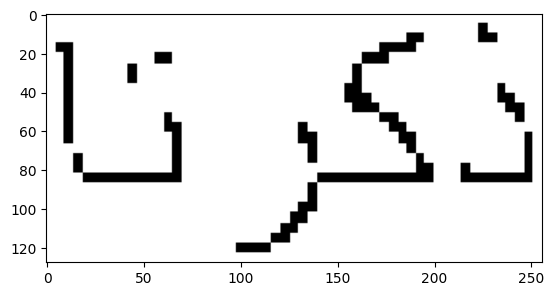

In [44]:
plt.imshow(images[15])

# Test DATA

In [45]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=True
)

Found 204 validated image filenames belonging to 3 classes.


# Training

## Backbone model

In [46]:
backbone=EfficientNetV2B0(weights='imagenet',include_top=False,input_shape=(128, 256, 3))

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [47]:
# CLASS_NAMES=np.unique(train_gen.labels)
CLASS_NAMES = np.unique(train_gen.labels) 
NB_CLASSES=len(CLASS_NAMES) # also len(train_gen.class_indices)
CLASS_NAMES,NB_CLASSES

(array([0, 1, 2]), 3)

In [48]:
input_data = backbone.input 
inner = backbone.output
##  Bidirectional lstm from scratch : 
inner = Reshape(target_shape=(32,1280), name='reshape')(inner)
inner = Bidirectional(LSTM(256, return_sequences=True), name = 'bilstm1')(inner)
inner = Bidirectional(LSTM(256, return_sequences=False), name = 'bilstm2')(inner)

inner = Dense(1000, activation='relu', kernel_initializer='he_normal', name='dense2')(inner)
## OUTPUT
inner = Dense(NB_CLASSES, kernel_initializer='he_normal',name='dense3')(inner)
y_pred = Activation('sigmoid', name='sigmoid')(inner)
model = Model(inputs=input_data, outputs=y_pred)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 128, 256, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 128, 256, 3)    │              0 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 64, 128, 32)    │            864 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 64, 128, 32)    │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 64, 128, 32)    │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 64, 128, 16)    │          4,608 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 64, 128, 16)    │             64 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 64, 128, 16)    │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_conv       │ (None, 32, 64, 64)     │          9,216 │ block1a_project_activ… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_bn         │ (None, 32, 64, 64)     │            256 │ block2a_expand_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_activation │ (None, 32, 64, 64)     │              0 │ block2a_expand_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_conv      │ (None, 32, 64, 32)     │          2,048 │ block2a_expand_activa… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_bn        │ (None, 32, 64, 32)     │            128 │ block2a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 11,158,003 (42.56 MB)

 Trainable params: 11,097,395 (42.33 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [49]:
model.compile(optimizer=Adam(LR),loss=LOSS_FUNCTION,metrics=metrics)

In [50]:
BATCH_SIZE=4
STEPS=int(train_gen.n / BATCH_SIZE) + 1
history=model.fit(train_gen,
                   validation_data=test_gen,
                   steps_per_epoch=STEPS,
                   epochs=EPOCHS,
                   verbose=2)

Epoch 1/30


E0000 00:00:1766363501.528398      20 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1766363507.203956      59 cuda_dnn.cc:529] Loaded cuDNN version 90300
/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your

204/204 - 82s - 400ms/step - accuracy: 0.7389 - binary_accuracy: 0.8259 - f1_score: 0.6732 - loss: 0.3949 - precision: 0.7519 - recall: 0.7131 - val_accuracy: 0.8382 - val_binary_accuracy: 0.8873 - val_f1_score: 0.8179 - val_loss: 0.2639 - val_precision: 0.8462 - val_recall: 0.8088
Epoch 2/30
204/204 - 6s - 29ms/step - accuracy: 0.9039 - binary_accuracy: 0.9331 - f1_score: 0.8905 - loss: 0.1810 - precision: 0.9021 - recall: 0.8966 - val_accuracy: 0.8725 - val_binary_accuracy: 0.9134 - val_f1_score: 0.8156 - val_loss: 0.2476 - val_precision: 0.8794 - val_recall: 0.8578
Epoch 3/30
204/204 - 6s - 29ms/step - accuracy: 0.9261 - binary_accuracy: 0.9495 - f1_score: 0.8942 - loss: 0.1465 - precision: 0.9269 - recall: 0.9212 - val_accuracy: 0.8824 - val_binary_accuracy: 0.9232 - val_f1_score: 0.8702 - val_loss: 0.1604 - val_precision: 0.8756 - val_recall: 0.8971
Epoch 4/30
204/204 - 6s - 29ms/step - accuracy: 0.9458 - binary_accuracy: 0.9655 - f1_score: 0.9312 - loss: 0.1117 - precision: 0.948

In [51]:
model.save("Gender_30_ep_5roots_bi_lstm.keras")

In [52]:
model=tf.keras.models.load_model("/kaggle/working/Gender_30_ep_5roots_bi_lstm.keras")

In [53]:
np.save("Gender_30_ep_5roots_bi_lstm_training_history.npy", history.history, allow_pickle=True)

In [54]:
history.history.keys()

dict_keys(['accuracy', 'binary_accuracy', 'f1_score', 'loss', 'precision', 'recall', 'val_accuracy', 'val_binary_accuracy', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])

In [55]:
keys=['binary_accuracy','f1_score','loss','precision', 'accuracy','recall']

/tmp/ipykernel_20/4161447496.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


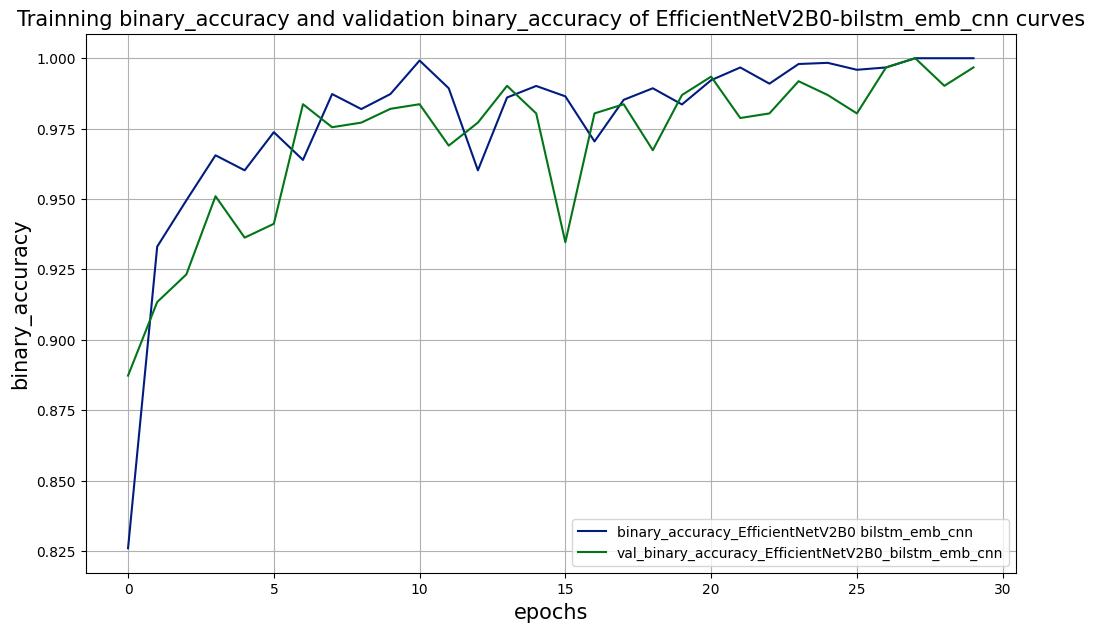

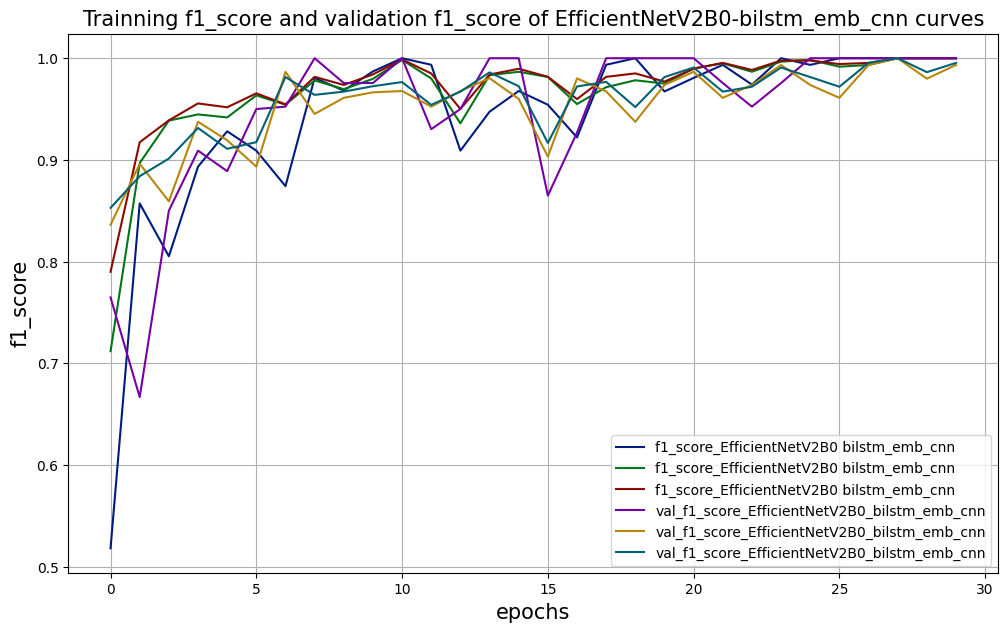

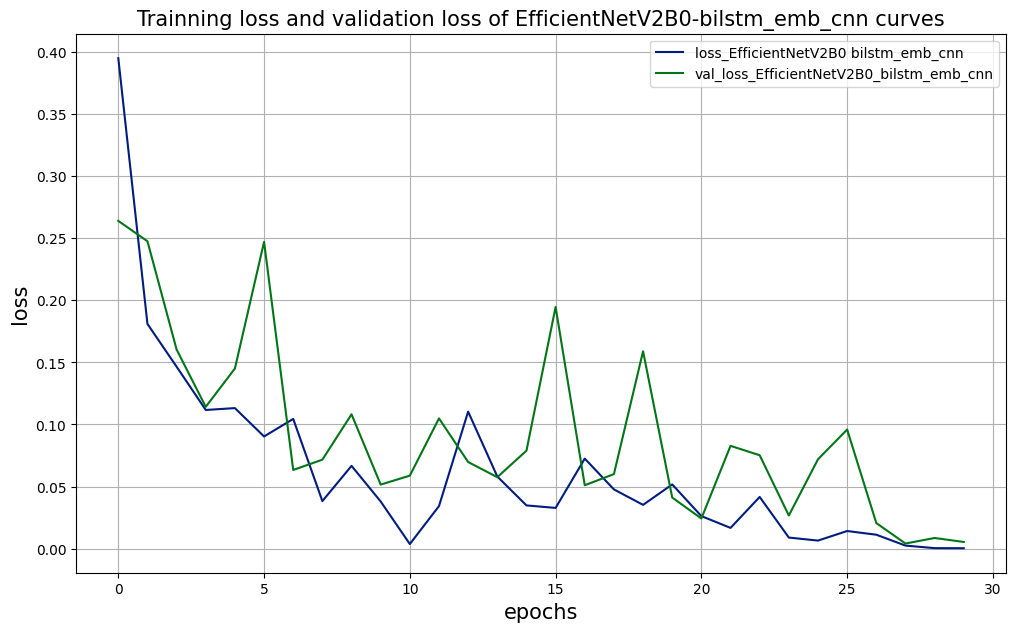

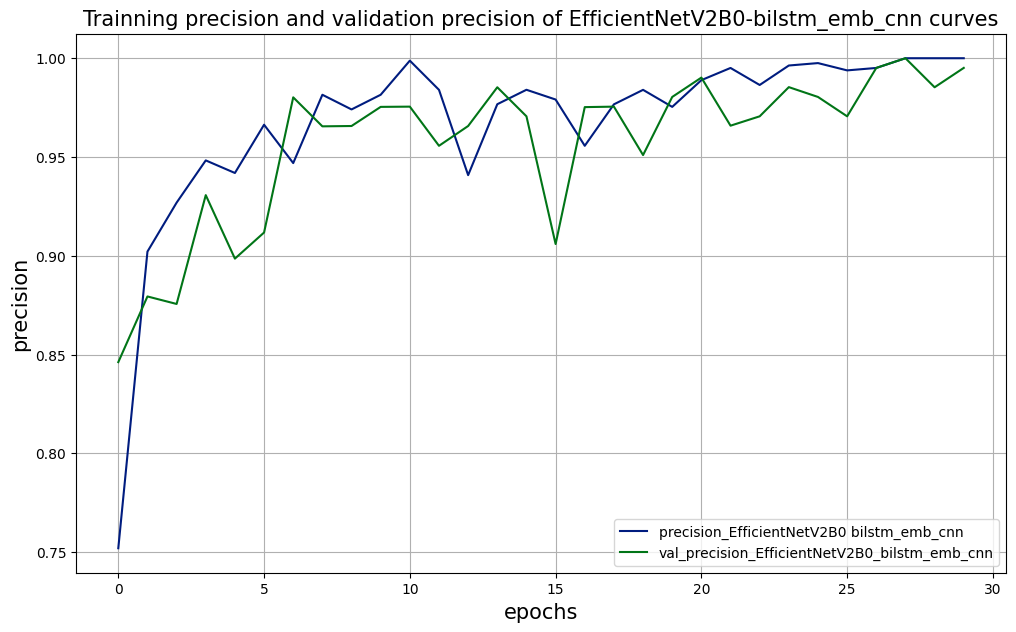

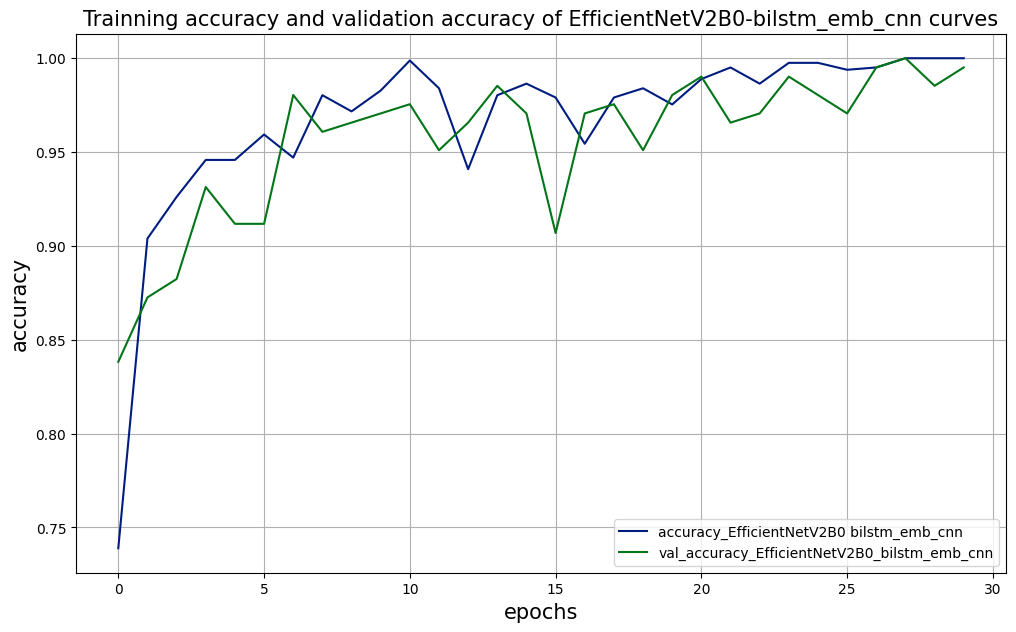

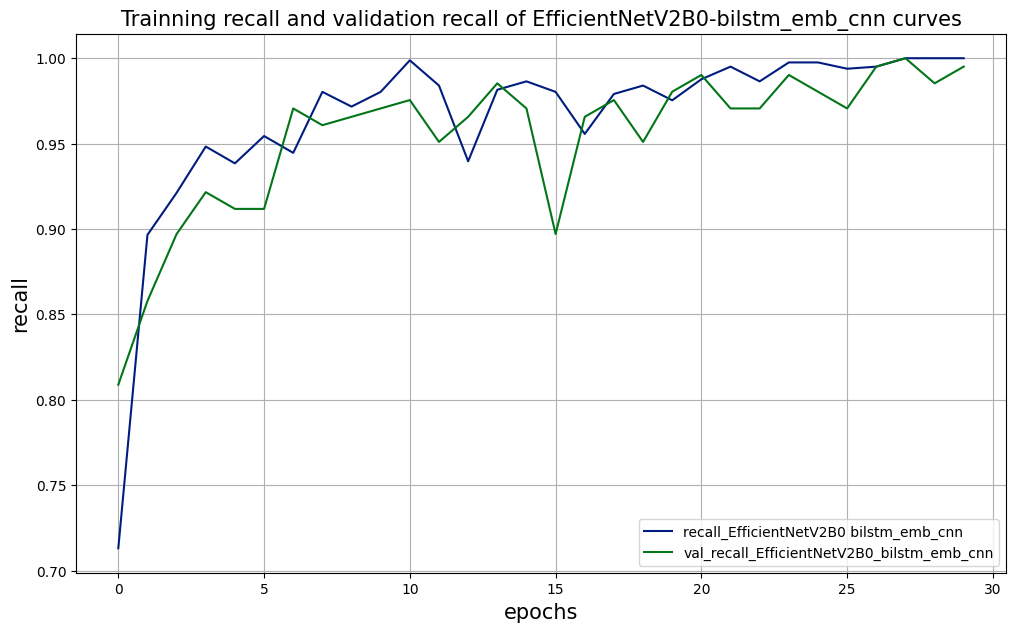

In [56]:
plt.style.use('seaborn-dark-palette')
for key in keys:
    plt.figure(figsize=(12,7))
    plt.plot(history.history[f'{key}'],label=f'{key}_EfficientNetV2B0 bilstm_emb_cnn',)
    plt.legend()
    plt.plot(history.history[f'val_{key}'],label=f'val_{key}_EfficientNetV2B0_bilstm_emb_cnn')
    plt.legend()
    plt.title(f'Trainning {key} and validation {key} of EfficientNetV2B0-bilstm_emb_cnn curves',fontsize=15)
    plt.xlabel('epochs',fontsize=15)
    plt.grid()
    plt.ylabel(key,fontsize=15)

In [57]:
res0_train=model.evaluate(train_gen)
res0_train

51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 1.0000 - binary_accuracy: 1.0000 - f1_score: 1.0000 - loss: 9.0234e-05 - precision: 1.0000 - recall: 1.0000


[8.322000212501734e-05,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 1., 1.], dtype=float32)>,
 1.0,
 1.0,
 1.0,
 1.0]

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step


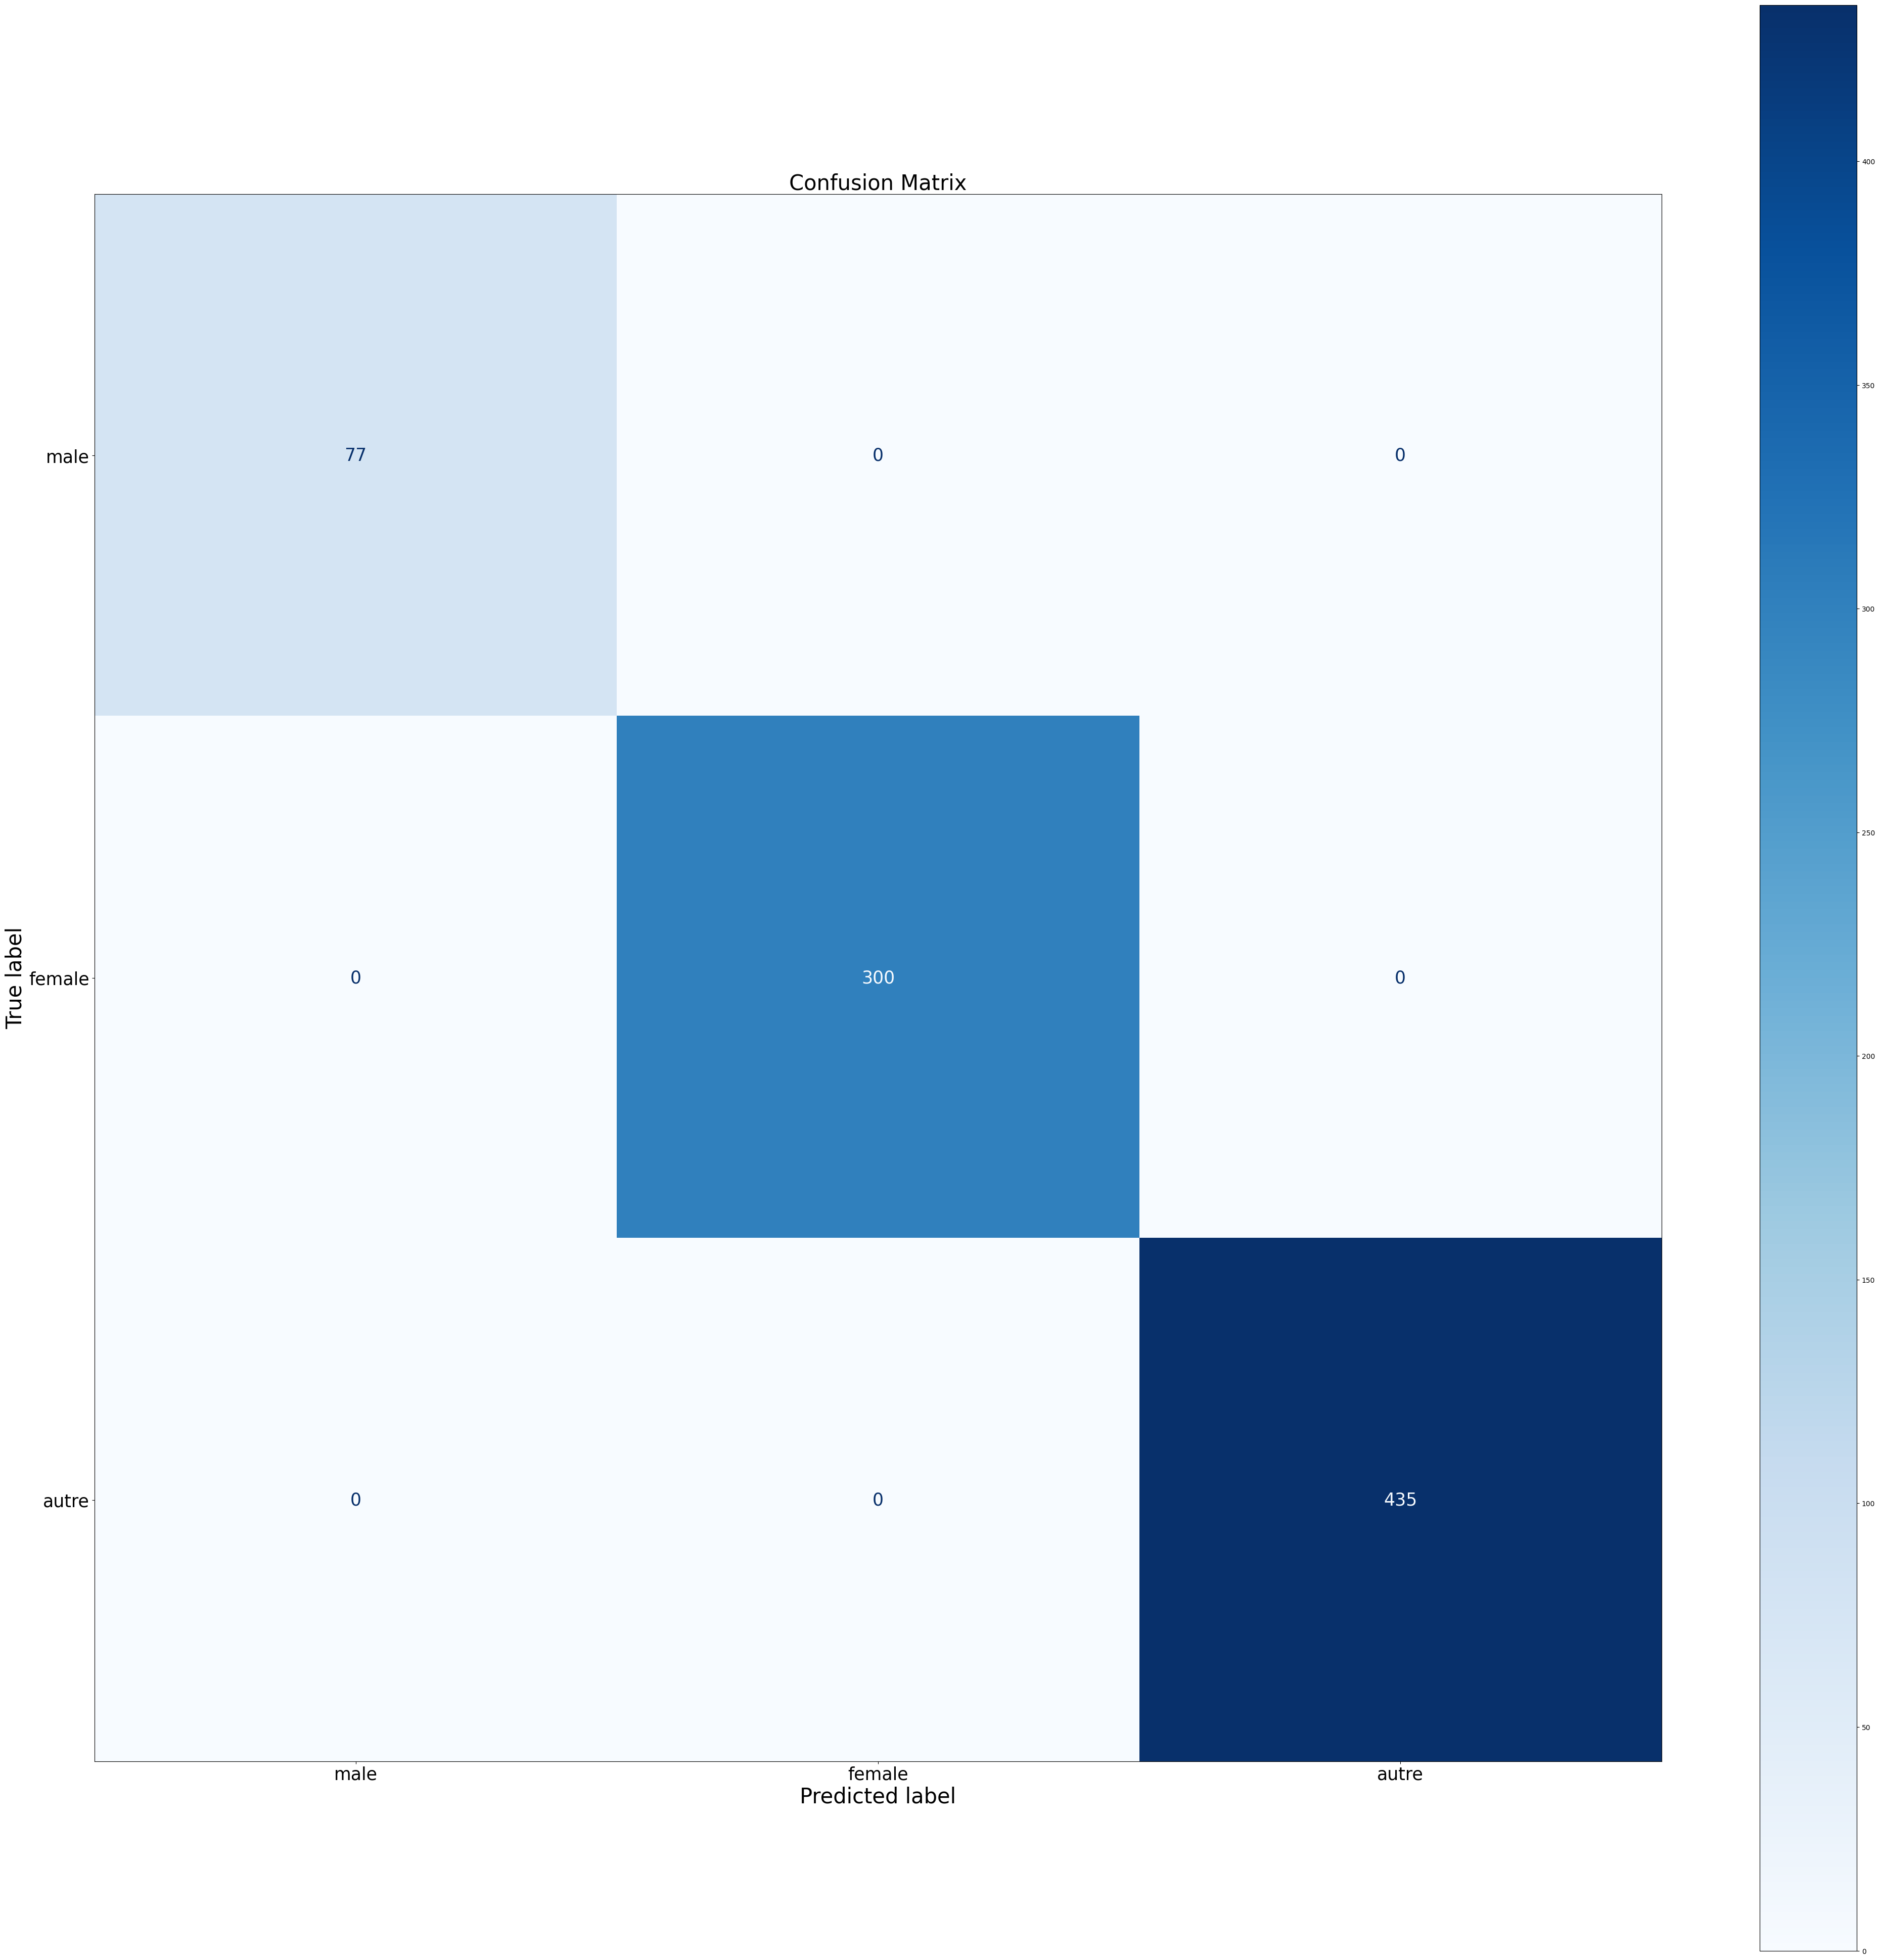

In [58]:
Y_res0_train= model.predict(train_gen)
Y_res0_train=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res0_train]
y_train_classes=[REFS_LABELS_MAP[y] for y in train_gen.labels]
cm=confusion_matrix(y_train_classes,Y_res0_train)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

In [59]:
from sklearn.metrics import classification_report
repport =classification_report(y_train_classes,Y_res0_train)
print(repport)

              precision    recall  f1-score   support

       autre       1.00      1.00      1.00        77
      female       1.00      1.00      1.00       300
        male       1.00      1.00      1.00       435

    accuracy                           1.00       812
   macro avg       1.00      1.00      1.00       812
weighted avg       1.00      1.00      1.00       812



##  shuffle=False in the test_gen:

In [60]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=False
)

Found 204 validated image filenames belonging to 3 classes.


In [61]:
res0_test=model.evaluate(test_gen)
res0_test

 5/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - binary_accuracy: 1.0000 - f1_score: 1.0000 - loss: 9.7684e-04 - precision: 1.0000 - recall: 1.0000

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9956 - binary_accuracy: 0.9971 - f1_score: 0.9967 - loss: 0.0051 - precision: 0.9956 - recall: 0.9956


[0.005403845105320215,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.        , 0.9933774 , 0.99539167], dtype=float32)>,
 0.9950980544090271,
 0.9950980544090271,
 0.9950980544090271,
 0.9967320561408997]

In [62]:
len(CLASS_NAMES)

3

### Metrics

#### Confusion Matrix

In [63]:
test_gen.class_indices

{'0': 0, '1': 1, '2': 2}

In [64]:
REFS_LABELS_MAP

{2: 'male', 1: 'female', 0: 'autre'}

In [65]:
Y_res0_test= model.predict(test_gen)
Y_res0_test=[np.argmax(y) for y in Y_res0_test]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [66]:
Y_res0_test[10:20],test_gen.labels[10:20]

([2, 2, 2, 1, 2, 2, 1, 2, 2, 2], [2, 2, 2, 1, 2, 2, 1, 2, 2, 2])

In [67]:
test_gen.filenames[:10]

['/kaggle/input/5-arabic-roots/corpus1/16/0/6_pr�sent/10_ghaeb/4_honna/Image_14_Arabic Transparent_9024.png',
 '/kaggle/input/5-arabic-roots/corpus1/0/0/5_pass�/11_ghaeb/4_hom/Image_18_Arabic Transparent_15847_6.png',
 '/kaggle/input/5-arabic-roots/corpus1/34/2/nom/2/4_feminin/7_marfou3/Image_14_Arabic Transparent_2419.png',
 '/kaggle/input/5-arabic-roots/corpus1/74/3/6_pr�sent/10_moukhatab/3_antouma/Image_14_Arabic Transparent_1659.png',
 '/kaggle/input/5-arabic-roots/corpus1/74/2/6_pr�sent/10_moukhatab/1_anti/Image_16_Arabic Transparent_1596.png',
 '/kaggle/input/5-arabic-roots/corpus1/76/3/5_pass�/11_ghaeb/0_houa/Image_18_Arabic Transparent_977_1.png',
 '/kaggle/input/5-arabic-roots/corpus1/34/3/5_pass�/10_moukhatab/1_antom/Image_14_Arabic Transparent_2143.png',
 '/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�sent/10_moukhatab/0_anta/Image_18_Arabic Transparent_15657.png',
 '/kaggle/input/5-arabic-roots/corpus1/34/0/6_pr�sent/10_moukhatab/4_antonna/Image_24_Arabic Transparent_2310.p

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


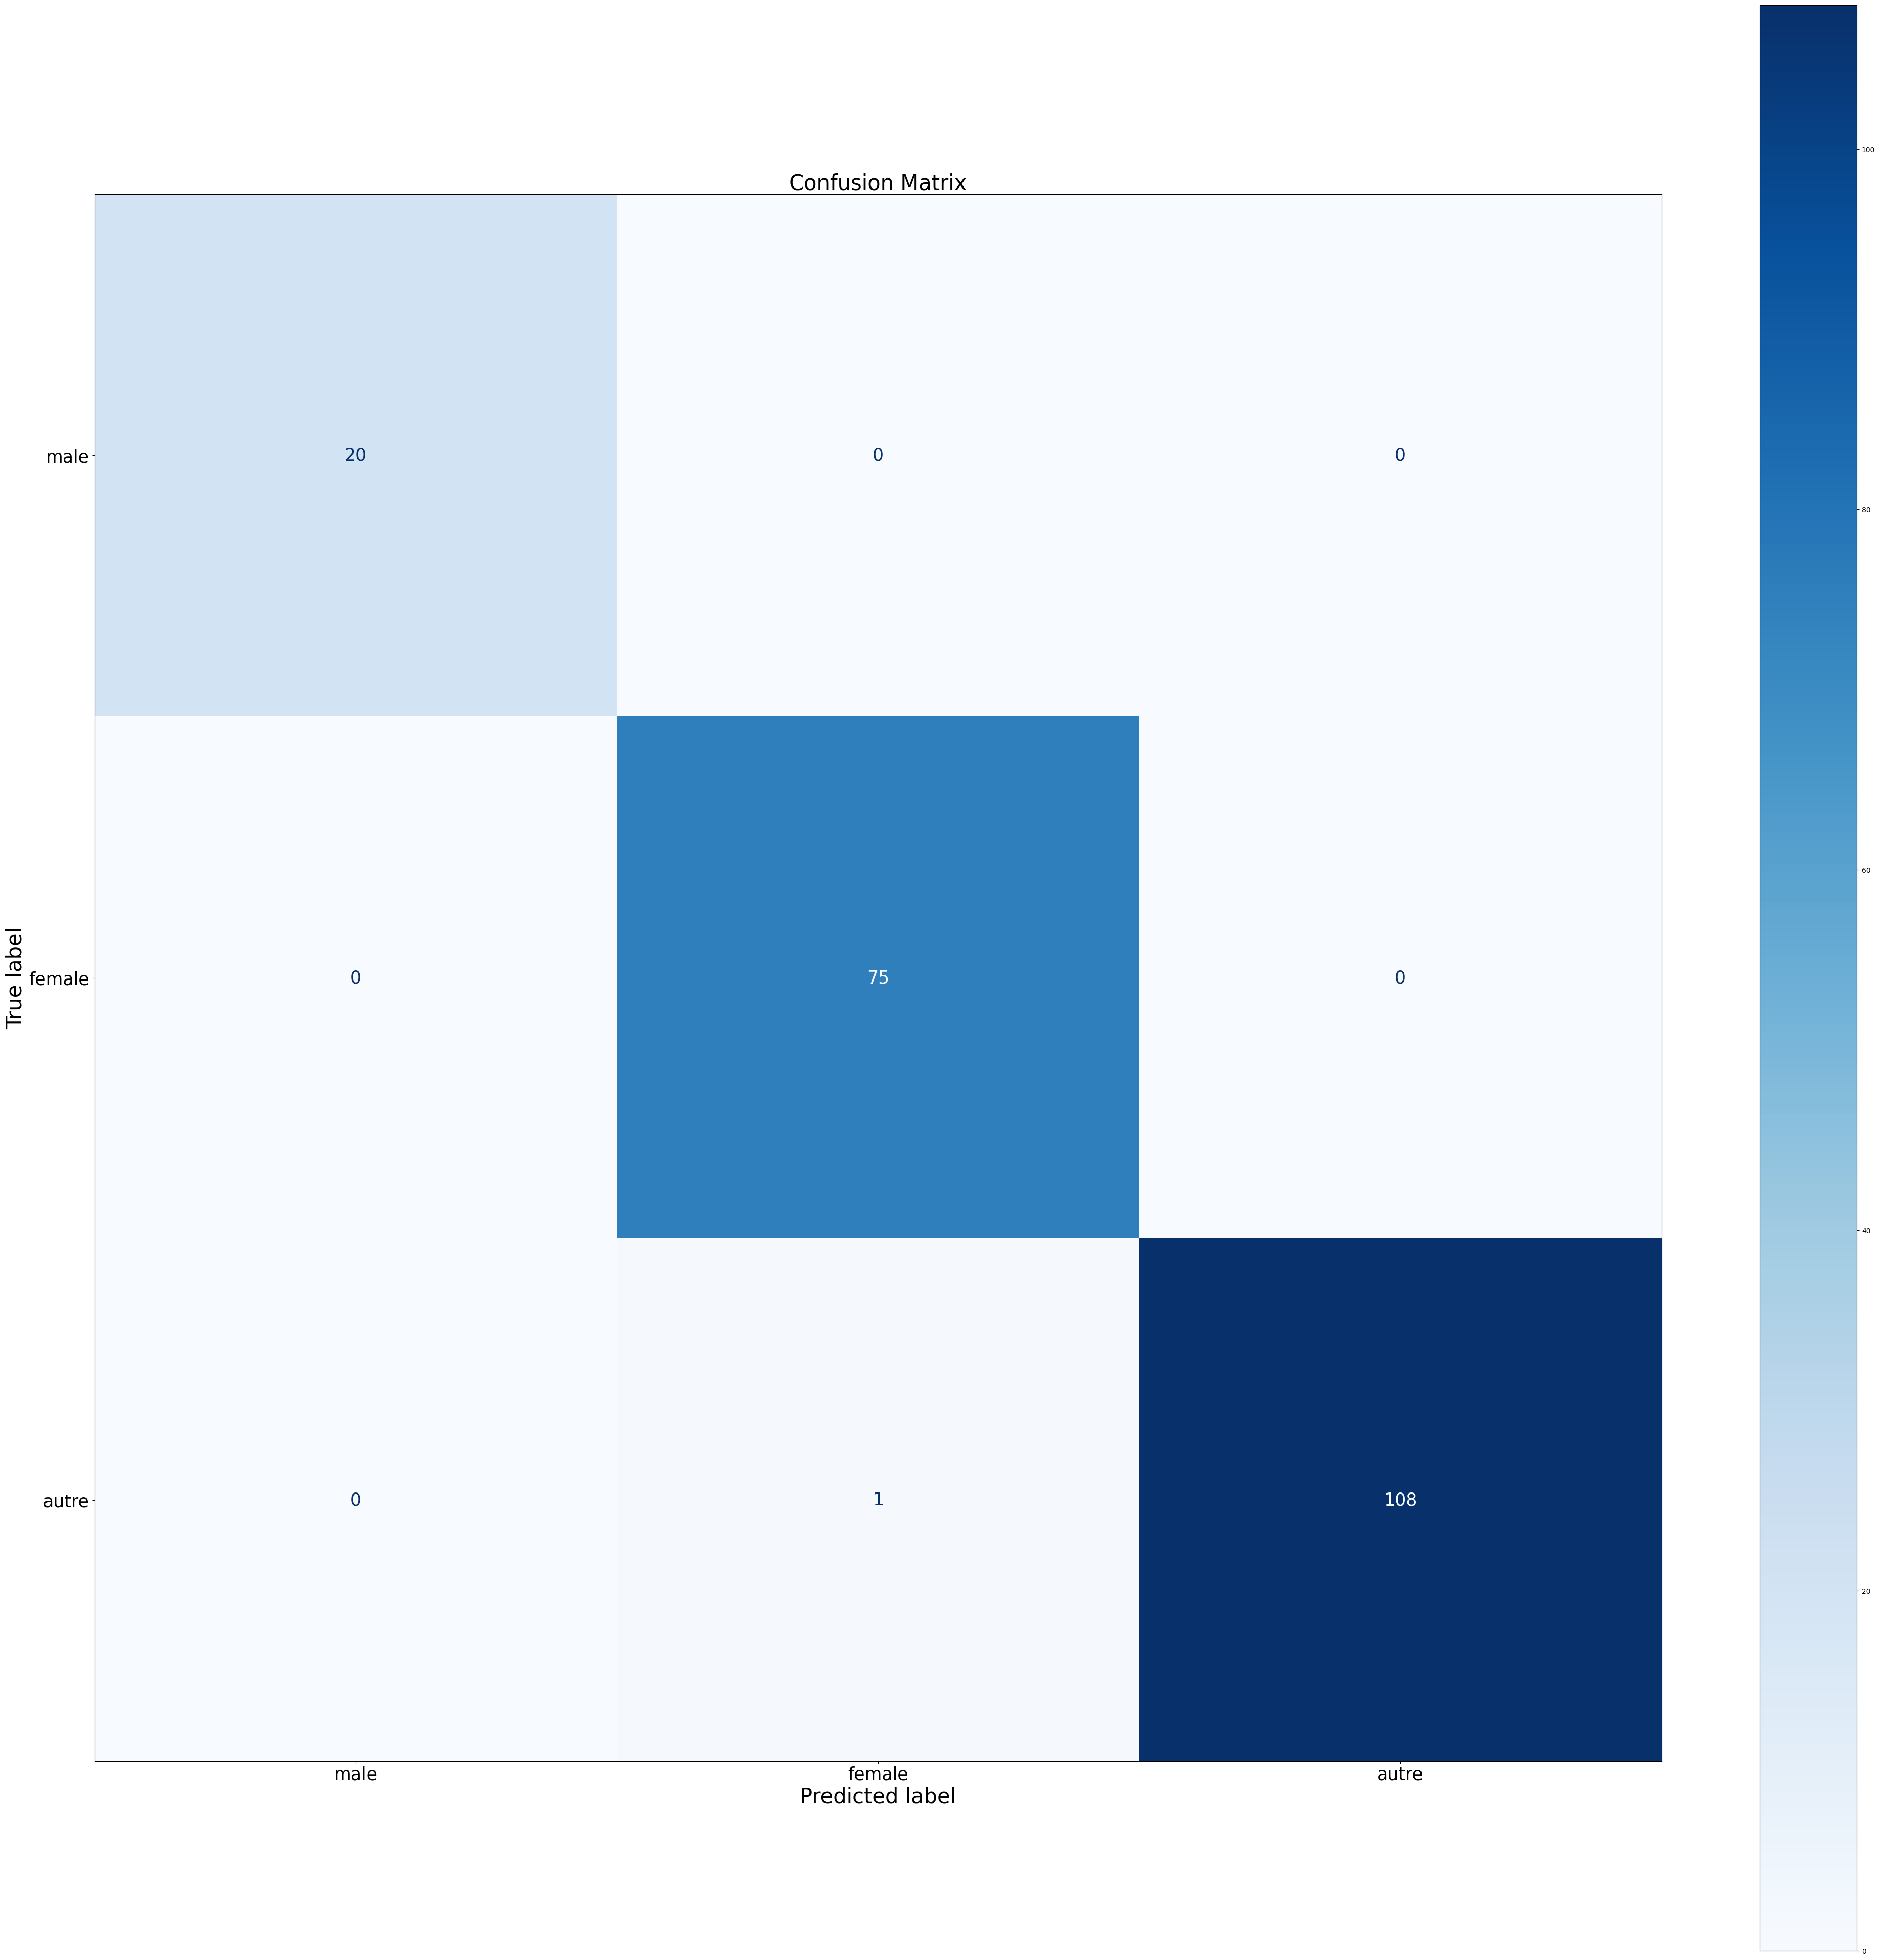

In [68]:
Y_res0_test= model.predict(test_gen)
Y_res0_test=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res0_test]
y_test_classes=[REFS_LABELS_MAP[y] for y in test_gen.labels]
cm=confusion_matrix(y_test_classes,Y_res0_test)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

#### Classification report

In [69]:
from sklearn.metrics import classification_report
repport =classification_report(y_test_classes,Y_res0_test)
print(repport)

              precision    recall  f1-score   support

       autre       1.00      1.00      1.00        20
      female       0.99      1.00      0.99        75
        male       1.00      0.99      1.00       109

    accuracy                           1.00       204
   macro avg       1.00      1.00      1.00       204
weighted avg       1.00      1.00      1.00       204



#### Top-5 accuracy

In [70]:
# from sklearn.metrics import top_k_accuracy_score
# y_test_scores=model.predict(test_gen)
# top_5_accuracy=top_k_accuracy_score(test_gen.labels,y_test_scores,k=5)
# print("the Top 5 accuracy score: "+ str(top_5_accuracy))

### Wrong test predictions 

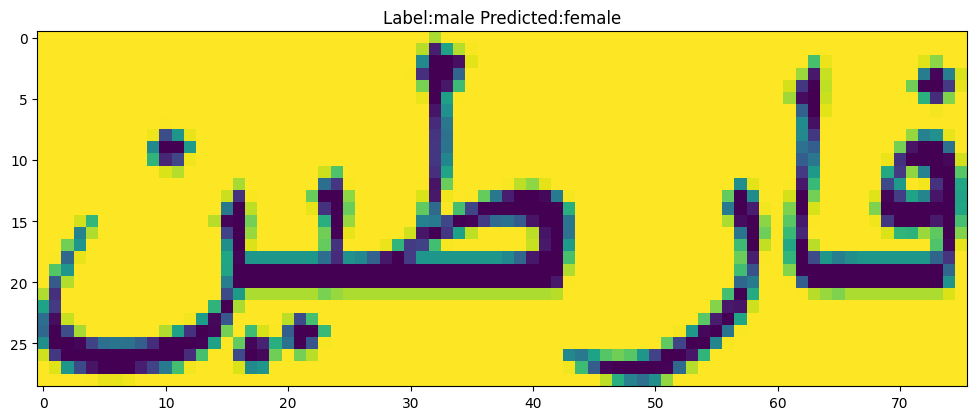

In [71]:
for index in range(len(Y_res0_test)):
    if Y_res0_test[index] !=y_test_classes[index]:
        img  =plt.imread(test_df['path'].values[index])
        plt.figure(figsize=(12,6))
        plt.title("Label:"+y_test_classes[index]+" Predicted:"+Y_res0_test[index])
        plt.imshow(img)